# `uq_analysis`: file-first UQ analysis (memory-friendly)

This notebook avoids building a single giant `df_all`.
Instead, it reads each eval CSV (ID + OOD) one at a time and produces small summary tables.

Key principle: **calibrate on ID validation only**, then apply calibration to ID test + OOD test.


In [1]:
# Setup + configuration.
# - Ensures project imports work from `<root>/notebooks`.
# - Selects the run tag to analyze (IMPORTANT: do not mix tags, e.g. _xs_ with _m_).

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import json
import sys

import numpy as np
import pandas as pd
import yaml


# Resolve project root
NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "scripts").is_dir() and (NOTEBOOK_DIR / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "scripts").is_dir() and (NOTEBOOK_DIR.parent / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ----------------
# USER KNOBS
# ----------------
RUN_TAG = "_m_"          # pick exactly one (e.g. "_xs_", "_m_", "_l_")
EVAL_ROOT = PROJECT_ROOT / "outputs" / "evals"
CONFIG_PATH = PROJECT_ROOT / "configs" / "uq_analysis.yaml"  # used for defaults only

# Datasets (labels must match what the eval scripts used in filenames)
ID_LABEL = "id"
OOD_LABELS_PRIMARY = ["geo", "rare_manu", "tail_multi"]
OOD_LABELS_SECONDARY = ["tail_mpy", "tail_odo", "tail_year_old"]
OOD_LABELS = OOD_LABELS_PRIMARY + OOD_LABELS_SECONDARY

# Large-error definition: top quantile of abs error under point baseline on ID test
LARGE_ERROR_QUANTILE = 0.95

# Calibration parameters (ID-val only)
N_RELIABILITY_BINS = 10


print("PROJECT_ROOT:", PROJECT_ROOT)
print("EVAL_ROOT   :", EVAL_ROOT)
print("RUN_TAG     :", RUN_TAG)
print("CONFIG_PATH :", CONFIG_PATH)


PROJECT_ROOT: /home/canelo/uncertainty_quantification
EVAL_ROOT   : /home/canelo/uncertainty_quantification/outputs/evals
RUN_TAG     : _m_
CONFIG_PATH : /home/canelo/uncertainty_quantification/configs/uq_analysis.yaml


In [2]:
# Discover eval directories for the selected RUN_TAG.
# This is intentionally simple and explicit to avoid mixing tags.

@dataclass(frozen=True)
class MethodSpec:
    key: str
    label: str
    head_type: str
    aleatoric_source: str
    epistemic_source: str
    kind: str  # "regression" | "ensemble" | "nf" | "dido"


# Core methods (as agreed): analytic + MC + ensemble (+ point baseline)
METHODS_CORE: List[MethodSpec] = [
    MethodSpec("point", "Point", "point", "none", "none", "regression"),
    MethodSpec("lpl_analytic", "Laplace (analytic)", "laplace", "analytic", "none", "regression"),
    MethodSpec("lpl_mc", "Laplace + MC", "laplace", "analytic", "mc", "regression"),
    MethodSpec("esm_lpl", "Laplace + ensemble", "laplace", "analytic", "ensemble", "ensemble"),
    MethodSpec("gau_analytic", "Gauss (analytic)", "gauss", "analytic", "none", "regression"),
    MethodSpec("gau_mc", "Gauss + MC", "gauss", "analytic", "mc", "regression"),
    MethodSpec("esm_gau", "Gauss + ensemble", "gauss", "analytic", "ensemble", "ensemble"),
]

# Auxiliary methods: NF, DIDO
METHODS_AUX: List[MethodSpec] = [
    MethodSpec("nf_lpl", "Laplace (NF)", "laplace", "nf", "none", "nf"),
    MethodSpec("nf_gau", "Gauss (NF)", "gauss", "nf", "none", "nf"),
    MethodSpec("dido_lpl", "Laplace + DIDO", "laplace", "analytic", "dido", "dido"),
    MethodSpec("dido_gau", "Gauss + DIDO", "gauss", "analytic", "dido", "dido"),
]


def _pick_latest_dir(glob_pat: str) -> Optional[Path]:
    matches = sorted(EVAL_ROOT.glob(glob_pat))
    return matches[-1] if matches else None


RUN_DIRS: Dict[str, Path] = {}

# Note: eval dir names encode the method and run tag.
RUN_DIRS["point"] = _pick_latest_dir(f"point{RUN_TAG}*")
RUN_DIRS["lpl"] = _pick_latest_dir(f"lpl{RUN_TAG}*")
RUN_DIRS["gau"] = _pick_latest_dir(f"gau{RUN_TAG}*")
RUN_DIRS["esm_lpl"] = _pick_latest_dir(f"esm_laplace_lpl{RUN_TAG}*")
RUN_DIRS["esm_gau"] = _pick_latest_dir(f"esm_gauss_gau{RUN_TAG}*")
RUN_DIRS["nf_lpl"] = _pick_latest_dir(f"nf_lpl{RUN_TAG}*")
RUN_DIRS["nf_gau"] = _pick_latest_dir(f"nf_gau{RUN_TAG}*")
RUN_DIRS["dido_lpl"] = _pick_latest_dir(f"dido_lpl{RUN_TAG}*")
RUN_DIRS["dido_gau"] = _pick_latest_dir(f"dido_gau{RUN_TAG}*")

print("Resolved eval dirs:")
for k, p in RUN_DIRS.items():
    print(f"  {k:10s}: {p}")


Resolved eval dirs:
  point     : /home/canelo/uncertainty_quantification/outputs/evals/point_m_20251211-144003_292628
  lpl       : /home/canelo/uncertainty_quantification/outputs/evals/lpl_m_20251211-144033_292629
  gau       : /home/canelo/uncertainty_quantification/outputs/evals/gau_m_20251211-144045_292630
  esm_lpl   : /home/canelo/uncertainty_quantification/outputs/evals/esm_laplace_lpl_m_20251213-024230_293790
  esm_gau   : /home/canelo/uncertainty_quantification/outputs/evals/esm_gauss_gau_m_20251213-024240_293795
  nf_lpl    : /home/canelo/uncertainty_quantification/outputs/evals/nf_lpl_m_20251212-212701_293697
  nf_gau    : /home/canelo/uncertainty_quantification/outputs/evals/nf_gau_m_20251212-212717_293698
  dido_lpl  : /home/canelo/uncertainty_quantification/outputs/evals/dido_lpl_m_20251212-212754_293699
  dido_gau  : /home/canelo/uncertainty_quantification/outputs/evals/dido_gau_m_20251212-212806_293700


In [3]:
# Helpers to load *one* eval file at a time and map to a common schema.
# This is the core memory-saving change: no global concat.

def _read_csv_usecols(path: Path, usecols: List[str]) -> pd.DataFrame:
    # Use intersection only to be robust to minor schema changes.
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    keep = [c for c in usecols if c in cols]
    return pd.read_csv(path, usecols=keep)


def load_id_regression(run_dir: Path, split: str, *, variant: str) -> pd.DataFrame:
    """variant: "point" | "analytic" | "mc" """
    run_dir = Path(run_dir)
    if variant == "point":
        path = run_dir / f"{split}_preds.csv"
        if not path.exists():
            path = run_dir / f"{split}_preds.csv"  # keep explicit
        df = _read_csv_usecols(path, ["id", "split", "head_type", "y_true", "y_pred"]) 
        df = df.rename(columns={"y_pred": "mu"})
        df["sigma_ale_raw"] = np.nan
        df["sigma_epi_raw"] = np.nan
        return df

    if variant == "analytic":
        # deterministic analytic preds
        fname = "preds_val.csv" if split == "val" else "test_preds.csv" if split == "test" else "preds_train.csv"
        path = run_dir / fname
        df = _read_csv_usecols(
            path,
            ["id", "split", "head_type", "y_true", "y_pred_det", "sigma_ale_raw"],
        )
        df = df.rename(columns={"y_pred_det": "mu"})
        df["sigma_epi_raw"] = np.nan
        return df

    if variant == "mc":
        fname = "mc_preds_val.csv" if split == "val" else "mc_preds_test.csv" if split == "test" else "mc_preds_train.csv"
        path = run_dir / fname
        df = _read_csv_usecols(
            path,
            ["id", "split", "head_type", "y_true", "y_pred_mc_mean", "sigma_ale_orig", "sigma_epi_orig"],
        )
        df = df.rename(
            columns={
                "y_pred_mc_mean": "mu",
                "sigma_ale_orig": "sigma_ale_raw",
                "sigma_epi_orig": "sigma_epi_raw",
            }
        )
        return df

    raise ValueError(f"unknown variant={variant}")


def load_id_ensemble(run_dir: Path, split: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    fname = f"ensemble_preds_{split}.csv"
    path = run_dir / fname
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            # Newer ensemble eval schema
            "y_pred_ens_mean",
            "sigma_ale_ens",
            "sigma_epi_ens",
            # Older/alternate names
            "y_pred_mean",
            "y_pred_method",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )

    # Standardize prediction
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})

    # Standardize sigmas
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})

    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})

    # Ensure required columns exist
    if "mu" not in df.columns:
        df["mu"] = np.nan
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df


def load_id_nf(run_dir: Path) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / "flow_eval_test.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig"],
    )
    df = df.rename(
        columns={
            "y_true_orig": "y_true",
            "y_pred_base_orig": "mu",
            "sigma_base_orig": "sigma_ale_raw",
        }
    )
    df["sigma_epi_raw"] = 0.0
    return df


def load_id_dido(run_dir: Path) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / "dido_test.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"],
    )
    return df


def load_ood_regression(run_dir: Path, label: str, *, variant: str | None = None) -> pd.DataFrame:
    """Load OOD eval outputs for a base regression run.

    variant:
      - None / "analytic" / "point": reads `ood_<label>_test.csv`
      - "mc": reads `mc_preds_ood_<label>.csv` (includes epistemic sigma)
    """
    run_dir = Path(run_dir)

    if variant == "mc":
        path = run_dir / f"mc_preds_ood_{label}.csv"
        df = _read_csv_usecols(
            path,
            [
                "id",
                "split",
                "head_type",
                "y_true",
                "y_pred_mc_mean",
                "y_pred_det",
                "sigma_ale_orig",
                "sigma_epi_orig",
            ],
        )
        if "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        elif "y_pred_det" in df.columns:
            df = df.rename(columns={"y_pred_det": "mu"})
        df = df.rename(
            columns={
                "sigma_ale_orig": "sigma_ale_raw",
                "sigma_epi_orig": "sigma_epi_raw",
            }
        )
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        if "sigma_epi_raw" not in df.columns:
            df["sigma_epi_raw"] = np.nan
        return df

    path = run_dir / f"ood_{label}_test.csv"
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_det",
            "y_pred_mean",
            "y_pred_method",
            "y_pred",
            "y_pred_mc_mean",
            "sigma_ale_raw",
            "sigma_epi_raw",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )

    # Standardize prediction -> mu
    if "y_pred_det" in df.columns:
        df = df.rename(columns={"y_pred_det": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    elif "y_pred" in df.columns:
        df = df.rename(columns={"y_pred": "mu"})
    elif "y_pred_mc_mean" in df.columns:
        df = df.rename(columns={"y_pred_mc_mean": "mu"})
    else:
        raise ValueError(f"No prediction column found in {path}")

    # Standardize sigmas (analytic heads typically only have aleatoric)
    if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})

    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan

    return df


def load_ood_nf(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / f"flow_eval_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig"],
    )
    df = df.rename(
        columns={
            "y_true_orig": "y_true",
            "y_pred_base_orig": "mu",
            "sigma_base_orig": "sigma_ale_raw",
        }
    )
    df["sigma_epi_raw"] = 0.0
    return df


def load_ood_dido(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / f"dido_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"],
    )
    return df


In [4]:
# Compute the large-error threshold tau from the point baseline on ID test.
# This tau is used across methods (method-agnostic definition).

point_dir = RUN_DIRS.get("point")
if point_dir is None:
    raise FileNotFoundError("No point eval dir found for RUN_TAG")

df_point_test = load_id_regression(point_dir, split="test", variant="point")
abs_err_point = np.abs(df_point_test["y_true"].to_numpy(float) - df_point_test["mu"].to_numpy(float))
LARGE_ERROR_TAU = float(np.quantile(abs_err_point, LARGE_ERROR_QUANTILE))
print(f"LARGE_ERROR_TAU (point ID test, q={LARGE_ERROR_QUANTILE:.2f}): {LARGE_ERROR_TAU:.4f}")


LARGE_ERROR_TAU (point ID test, q=0.95): 10443.1934


In [5]:
# Fit calibration parameters on ID validation by minimizing a proper scoring rule
# (toggle between NLL and CRPS). alpha scales aleatoric variance; beta scales
# epistemic variance (per method). Calibration is fit on ID-val only.
#
# We do a 2-stage search:
#  1) coarse log-spaced grid over a wide range
#  2) fine log-spaced grid around the best coarse value

from scripts.uq_eval import gaussian_nll
from scipy.stats import norm

# --- Objective toggle ---
CALIBRATION_OBJECTIVE = 'crps'  # 'nll' or 'crps'
CALIB_OBJ = str(CALIBRATION_OBJECTIVE).strip().lower()
if CALIB_OBJ not in {'nll', 'crps'}:
    raise ValueError(f'Unknown CALIBRATION_OBJECTIVE={CALIBRATION_OBJECTIVE!r}')

def gaussian_crps_mean(y_true, y_pred, sigma):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float('nan')
    y = y_true[mask]
    m = y_pred[mask]
    s = np.clip(sigma[mask], 1e-8, None)
    z = (y - m) / s
    crps = s * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

def _calibration_score(y_true, y_pred, sigma):
    if CALIB_OBJ == 'nll':
        return gaussian_nll(y_true, y_pred, sigma)
    return gaussian_crps_mean(y_true, y_pred, sigma)

# --- Grid settings (adjustable) ---
ALPHA_LOG10_RANGE = (-3, 3)
ALPHA_COARSE_N = 21
ALPHA_FINE_SPAN_DECADES = 0.5   # ±0.5 decades (~×3.16) around the coarse best
ALPHA_FINE_N = 41

BETA_LOG10_RANGE = (-8, 3)      # allow much smaller betas to test “near-zero” optima
BETA_COARSE_N = 25
BETA_FINE_SPAN_DECADES = 0.5
BETA_FINE_N = 41


def _logspace_range(log10_range, n):
    lo, hi = log10_range
    return np.logspace(lo, hi, n)


def _refine_grid(best, *, span_decades, n, log10_range):
    if not np.isfinite(best) or best <= 0:
        return np.array([], dtype=float)
    lo, hi = log10_range
    g = best * np.logspace(-span_decades, span_decades, n)
    g = g[(g >= 10**lo) & (g <= 10**hi)]
    return g


def _grid_search_alpha(y_true, mu, sigma_ale, coarse_grid=None):
    y_true = np.asarray(y_true, float)
    mu = np.asarray(mu, float)
    sigma_ale = np.asarray(sigma_ale, float)
    mask = np.isfinite(y_true) & np.isfinite(mu) & np.isfinite(sigma_ale) & (sigma_ale > 0)
    if not np.any(mask):
        return float('nan')

    y = y_true[mask]
    m = mu[mask]
    s = sigma_ale[mask]

    coarse = _logspace_range(ALPHA_LOG10_RANGE, ALPHA_COARSE_N) if coarse_grid is None else np.asarray(coarse_grid, float)

    best_a, best_score = float('nan'), float('inf')
    for a in coarse:
        sigma = np.sqrt(a) * s
        score = _calibration_score(y, m, sigma)
        if np.isfinite(score) and score < best_score:
            best_score, best_a = score, float(a)

    fine = _refine_grid(best_a, span_decades=ALPHA_FINE_SPAN_DECADES, n=ALPHA_FINE_N, log10_range=ALPHA_LOG10_RANGE)
    for a in fine:
        sigma = np.sqrt(a) * s
        score = _calibration_score(y, m, sigma)
        if np.isfinite(score) and score < best_score:
            best_score, best_a = score, float(a)

    return float(best_a)


def _grid_search_beta(y_true, mu, sigma_ale, sigma_epi, *, alpha_value, coarse_grid=None):
    y_true = np.asarray(y_true, float)
    mu = np.asarray(mu, float)
    sigma_ale = np.asarray(sigma_ale, float)
    sigma_epi = np.asarray(sigma_epi, float)

    mask = (
        np.isfinite(y_true)
        & np.isfinite(mu)
        & np.isfinite(sigma_ale)
        & np.isfinite(sigma_epi)
        & (sigma_ale >= 0)
        & (sigma_epi >= 0)
    )
    if not np.any(mask) or not np.isfinite(alpha_value) or alpha_value < 0:
        return float('nan')

    y = y_true[mask]
    m = mu[mask]
    s_a = sigma_ale[mask]
    s_e = sigma_epi[mask]

    coarse = _logspace_range(BETA_LOG10_RANGE, BETA_COARSE_N) if coarse_grid is None else np.asarray(coarse_grid, float)

    best_b, best_score = float('nan'), float('inf')
    for b in coarse:
        s_total = np.sqrt(np.maximum(alpha_value * s_a**2 + b * s_e**2, 1e-12))
        score = _calibration_score(y, m, s_total)
        if np.isfinite(score) and score < best_score:
            best_score, best_b = score, float(b)

    fine = _refine_grid(best_b, span_decades=BETA_FINE_SPAN_DECADES, n=BETA_FINE_N, log10_range=BETA_LOG10_RANGE)
    for b in fine:
        s_total = np.sqrt(np.maximum(alpha_value * s_a**2 + b * s_e**2, 1e-12))
        score = _calibration_score(y, m, s_total)
        if np.isfinite(score) and score < best_score:
            best_score, best_b = score, float(b)

    return float(best_b)


alpha: Dict[Tuple[str, str], float] = {}
beta: Dict[Tuple[str, str, str], float] = {}

# Fit alpha on analytic val (Laplace/Gauss)
for head_key, head_type in [("lpl", "laplace"), ("gau", "gauss")]:
    run_dir = RUN_DIRS.get(head_key)
    if run_dir is None:
        continue
    df_val = load_id_regression(run_dir, split="val", variant="analytic")
    a = _grid_search_alpha(df_val["y_true"], df_val["mu"], df_val["sigma_ale_raw"])
    alpha[(head_type, "analytic")] = float(a)

print(f"alpha ({CALIB_OBJ.upper()}-calibrated, coarse→fine):")
for k, v in sorted(alpha.items()):
    print(" ", k, "=", v)

# Fit beta on val for MC (Laplace/Gauss)
for head_key, head_type in [("lpl", "laplace"), ("gau", "gauss")]:
    run_dir = RUN_DIRS.get(head_key)
    if run_dir is None:
        continue
    a = alpha.get((head_type, "analytic"), float("nan"))
    df_val_mc = load_id_regression(run_dir, split="val", variant="mc")
    b = _grid_search_beta(
        df_val_mc["y_true"],
        df_val_mc["mu"],
        df_val_mc["sigma_ale_raw"],
        df_val_mc["sigma_epi_raw"],
        alpha_value=a,
    )
    beta[(head_type, "analytic", "mc")] = float(b)

# Fit beta on val for ensembles (if available)
for head_key, head_type, ens_key in [("lpl", "laplace", "esm_lpl"), ("gau", "gauss", "esm_gau")]:
    ens_dir = RUN_DIRS.get(ens_key)
    if ens_dir is None:
        continue
    a = alpha.get((head_type, "analytic"), float("nan"))
    df_val_ens = load_id_ensemble(ens_dir, split="val")
    b = _grid_search_beta(
        df_val_ens["y_true"],
        df_val_ens["mu"],
        df_val_ens["sigma_ale_raw"],
        df_val_ens["sigma_epi_raw"],
        alpha_value=a,
    )
    beta[(head_type, "analytic", "ensemble")] = float(b)

print(f"beta ({CALIB_OBJ.upper()}-calibrated, coarse→fine):")
for k, v in sorted(beta.items()):
    print(" ", k, "=", v)



alpha (CRPS-calibrated, coarse→fine):
  ('gauss', 'analytic') = 0.4466835921509629
  ('laplace', 'analytic') = 0.4731512589614803
beta (CRPS-calibrated, coarse→fine):
  ('gauss', 'analytic', 'ensemble') = 1e-08
  ('gauss', 'analytic', 'mc') = 1e-08
  ('laplace', 'analytic', 'ensemble') = 1e-08
  ('laplace', 'analytic', 'mc') = 1e-08


In [6]:
# Compute core ID-test metrics (file-first).
# Produces a small summary table; does NOT build a giant df.

from scripts.uq_eval import gaussian_nll
from scipy.stats import norm


def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))


def calibrated_sigmas(
    *,
    head_type: str,
    ale_src: str,
    epi_src: str,
    sigma_ale_raw: np.ndarray,
    sigma_epi_raw: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # If NF doesn't have its own alpha (no val flow files), fall back to analytic alpha.
    def _alpha_lookup(ht: str, asrc: str) -> float:
        if (ht, asrc) in alpha:
            return float(alpha[(ht, asrc)])
        if asrc == "nf" and (ht, "analytic") in alpha:
            return float(alpha[(ht, "analytic")])
        return 1.0

    a = _alpha_lookup(head_type, ale_src)
    b = float(beta.get((head_type, ale_src, epi_src), 1.0))
    s_a2 = a * (np.asarray(sigma_ale_raw, float) ** 2)
    s_e2 = b * (np.asarray(sigma_epi_raw, float) ** 2)
    s_a = np.sqrt(np.maximum(s_a2, 0.0))
    s_e = np.sqrt(np.maximum(s_e2, 0.0))
    s_t = np.sqrt(np.maximum(s_a2 + s_e2, 0.0))
    return s_a, s_e, s_t


def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["lpl"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["lpl"], split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["gau"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["gau"], split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(RUN_DIRS["esm_lpl"], split="test")
        return load_id_ensemble(RUN_DIRS["esm_gau"], split="test")
    raise ValueError(f"Unhandled core spec: {spec}")


rows = []
for spec in METHODS_CORE:
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    # Calibrated sigmas (point has NaNs -> treat as 0)
    if spec.head_type == "point":
        sigma_total = np.full_like(mu, np.nan, dtype=float)
        mae = float(np.mean(np.abs(y - mu)))
        rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
        rows.append({"method": spec.label, "n": int(len(df)), "MAE": mae, "RMSE": rmse, "NLL": np.nan, "CRPS": np.nan, "mean_sigma_total": np.nan})
        continue

    s_a, s_e, s_t = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )

    mae = float(np.mean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))

    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t) & (s_t > 0)
    nll = float(gaussian_nll(y[mask], mu[mask], s_t[mask])) if np.any(mask) else float("nan")
    crps = gaussian_crps_mean(y, mu, s_t)

    rows.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(df)),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps,
            "mean_sigma_total": float(np.nanmean(s_t)),
        }
    )

df_core_metrics = pd.DataFrame(rows)
display(df_core_metrics)


,method,n,MAE,RMSE,NLL,CRPS,mean_sigma_total,head_type,aleatoric_source,epistemic_source
0,Point,31697,2988.870190,5395.862307,NaN,NaN,NaN,NaN,NaN,NaN
1,Laplace (analytic),31697,2648.244218,4925.746434,10.771364,1982.825485,2954.895490,laplace,analytic,none
2,Laplace + MC,31697,2660.404512,4888.146942,10.727218,1980.797005,2954.895313,laplace,analytic,mc
3,Laplace + ensemble,31697,1944.417364,3743.533684,9.264058,1480.355711,2934.325081,laplace,analytic,ensemble
4,Gauss (analytic),31697,4536.885982,8098.389074,10.305762,3361.182087,5158.259219,gauss,analytic,none
5,Gauss + MC,31697,4604.487897,8090.950003,10.315415,3391.575919,5158.259247,gauss,analytic,mc
6,Gauss + ensemble,31697,4178.156142,7504.919292,9.890363,3092.503537,5333.259041,gauss,analytic,ensemble


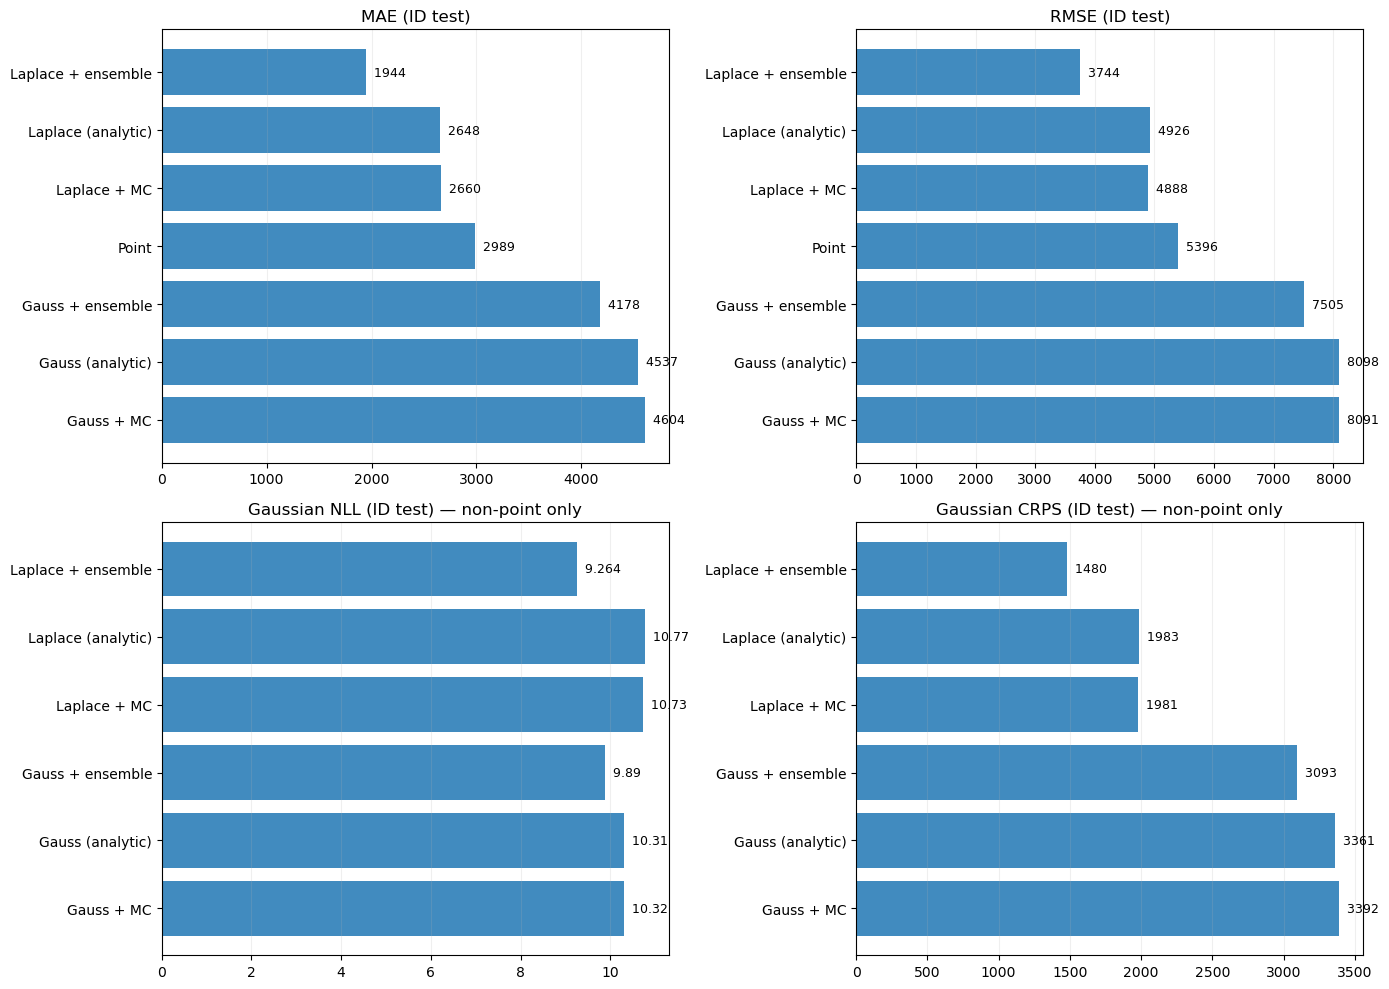

In [7]:
# Visualize core ID-test metrics from df_core_metrics.
# Note: point baseline is included for MAE/RMSE, but excluded from probabilistic metrics (NLL/CRPS).

import numpy as np
import matplotlib.pyplot as plt

dfm = df_core_metrics.copy()

# Consistent ordering (best-to-worst by MAE)
method_order = dfm.sort_values("MAE")["method"].tolist()

def _barh(ax, df, metric, title):
    sub = df.set_index("method").reindex(method_order).reset_index()
    sub = sub[np.isfinite(sub[metric].to_numpy(float))]
    if sub.empty:
        ax.set_axis_off()
        ax.set_title(f"{title} (no data)")
        return

    y = np.arange(len(sub))
    vals = sub[metric].to_numpy(float)

    ax.barh(y, vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["method"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)

    # annotate values
    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.4g}", va="center", ha="left", fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Accuracy metrics (include point)
_barh(axes[0], dfm, "MAE", "MAE (ID test)")
_barh(axes[1], dfm, "RMSE", "RMSE (ID test)")

# Probabilistic metrics (exclude point implicitly via NaNs)
df_prob = dfm[dfm["head_type"] != "point"].copy()
_barh(axes[2], df_prob, "NLL", "Gaussian NLL (ID test) — non-point only")
_barh(axes[3], df_prob, "CRPS", "Gaussian CRPS (ID test) — non-point only")

plt.tight_layout()
plt.show()


,method,cov_raw_10,cov_raw_20,cov_raw_30,cov_raw_40,cov_raw_50,cov_raw_60,cov_raw_70,cov_raw_80,cov_raw_90,cov_10,cov_20,cov_30,cov_40,cov_50,cov_60,cov_70,cov_80,cov_90,ece
0,Laplace (analytic),0.159290,0.312017,0.453923,0.577436,0.678897,0.763858,0.833297,0.890621,0.938732,0.109758,0.218664,0.326088,0.430514,0.526391,0.617598,0.700823,0.779821,0.859387,2.118076
1,Laplace + MC,0.185507,0.359750,0.509954,0.639146,0.736063,0.809856,0.870145,0.915923,0.955516,0.107076,0.216866,0.322365,0.423258,0.520775,0.614506,0.700350,0.779411,0.857084,1.874450
2,Laplace + ensemble,0.246553,0.450043,0.604411,0.719185,0.806859,0.870871,0.918036,0.953750,0.979462,0.166199,0.318737,0.449727,0.561504,0.657949,0.740165,0.809130,0.871218,0.924914,11.106028
3,Gauss (analytic),0.178534,0.346247,0.505884,0.638199,0.744234,0.823737,0.883333,0.926176,0.957346,0.120295,0.237625,0.350759,0.463545,0.573303,0.667918,0.754488,0.828564,0.898035,4.427373
4,Gauss + MC,0.201376,0.387576,0.555636,0.691296,0.788907,0.859861,0.909928,0.942140,0.965612,0.112313,0.222608,0.331577,0.441714,0.554027,0.654668,0.742657,0.821150,0.894501,3.180147
5,Gauss + ensemble,0.215951,0.406221,0.561567,0.698583,0.794839,0.863930,0.911790,0.946935,0.971859,0.142474,0.279364,0.402025,0.510805,0.622015,0.716093,0.794081,0.861596,0.918036,8.294336


,method,ece
0,Laplace (analytic),2.118076
1,Laplace + MC,1.874450
2,Laplace + ensemble,11.106028
3,Gauss (analytic),4.427373
4,Gauss + MC,3.180147
5,Gauss + ensemble,8.294336


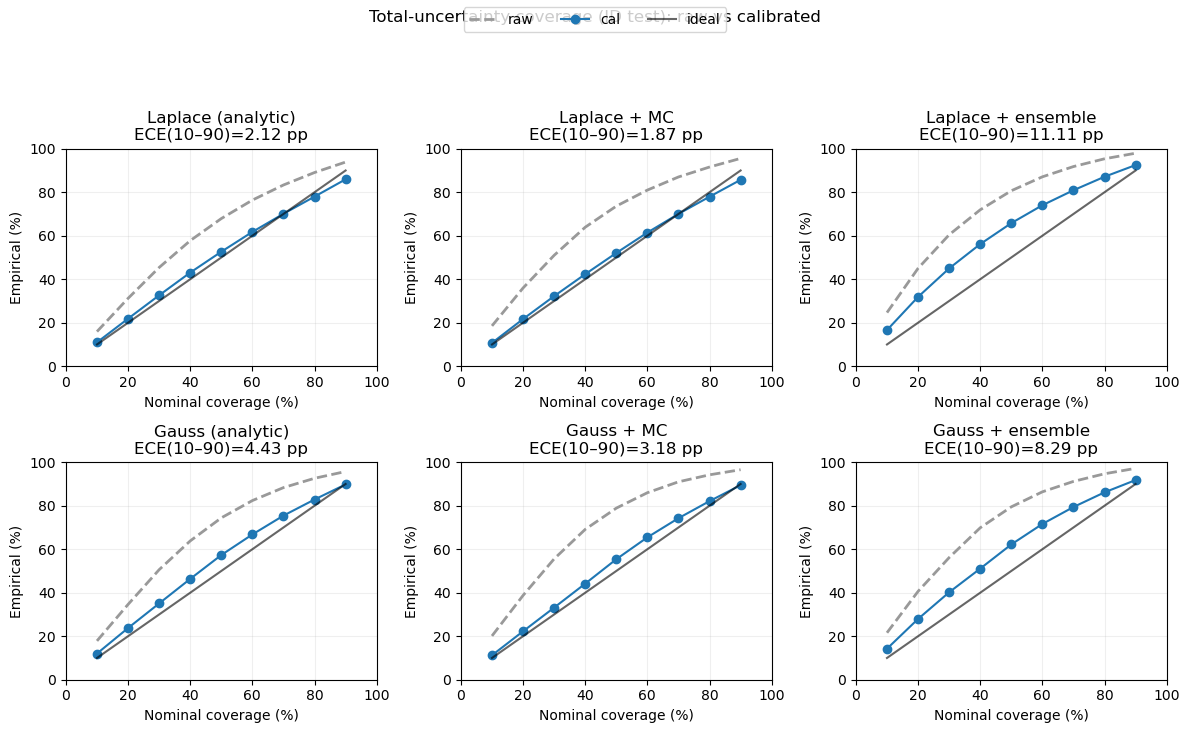

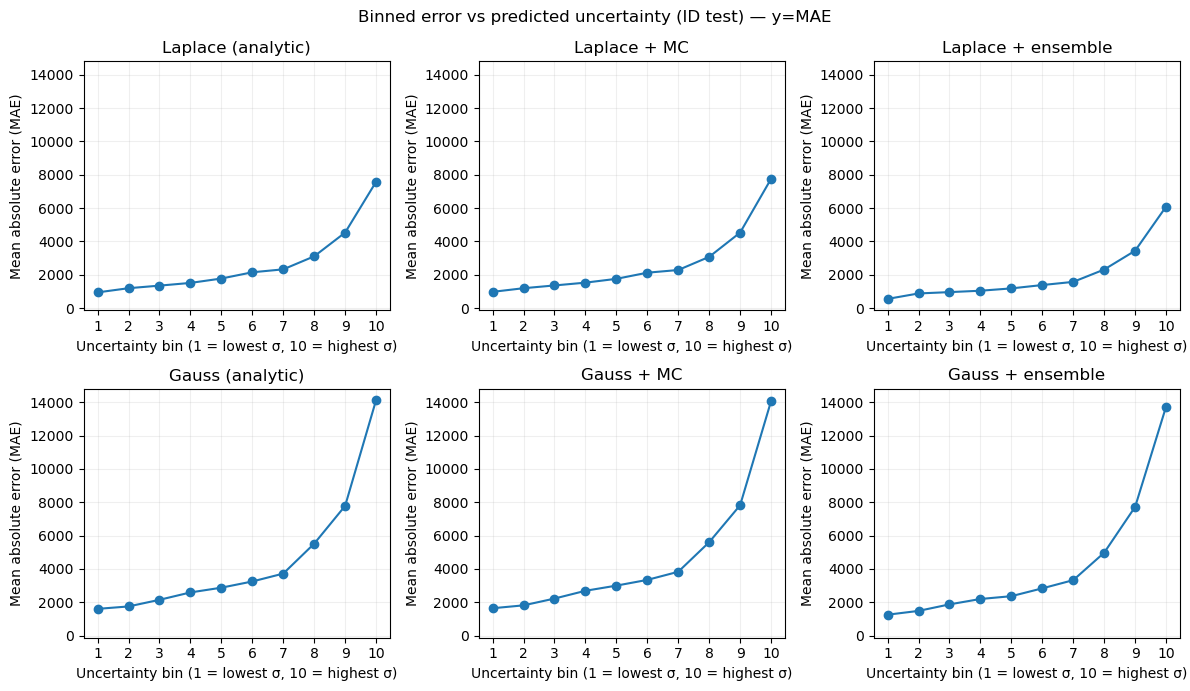

In [8]:
# Calibration diagnostics on ID test (core methods).
# - Coverage at 10–90% (step 10) + ECE (mean abs coverage error over 10–90, in percentage points)
# - Also plots "before calibration" (raw sigmas) as a grey dashed line.
# - Replaces the variance-vs-error² scatter with an intuitive binned plot:
#     bin by predicted uncertainty (σ_total), then plot mean MAE or mean CRPS per bin (toggle).

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

# Toggle for the binned plot y-axis:
BIN_METRIC = "mae"  # "mae" or "crps"

nominal_levels_plot = np.arange(10, 100, 10)  # 10..90
z_for_level = {lvl: float(norm.ppf((1 + (lvl / 100.0)) / 2.0)) for lvl in nominal_levels_plot}

def compute_coverage_points(y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, levels, z_map):
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)
    err = np.abs(y - mu)
    out = {}
    mask_base = np.isfinite(err) & np.isfinite(sigma_total) & (sigma_total > 0)
    for lvl in levels:
        z = z_map[lvl]
        out[lvl] = float(np.mean(err[mask_base] <= z * sigma_total[mask_base])) if np.any(mask_base) else float("nan")
    return out

def gaussian_crps_per_row(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    out = np.full_like(y, np.nan, dtype=float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return out
    yy = y[mask]
    mm = mu[mask]
    ss = np.clip(sigma[mask], 1e-8, None)
    z = (yy - mm) / ss
    crps = ss * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    out[mask] = crps
    return out

def compute_bins_and_means(
    y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, *, n_bins: int
) -> pd.DataFrame:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)

    abs_err = np.abs(y - mu)
    crps = gaussian_crps_per_row(y, mu, sigma_total)

    mask = np.isfinite(sigma_total) & (sigma_total > 0) & np.isfinite(abs_err)
    if not np.any(mask):
        return pd.DataFrame(columns=["bin", "bin_sigma_mean", "bin_mae_mean", "bin_crps_mean", "n"])

    s = sigma_total[mask]
    ae = abs_err[mask]
    cr = crps[mask]

    # Equal-count bins by predicted σ (more intuitive than variance)
    bins = pd.qcut(s, n_bins, labels=False, duplicates="drop")
    df = pd.DataFrame({"bin": bins.astype(int) + 1, "sigma": s, "abs_err": ae, "crps": cr})

    out = (
        df.groupby("bin")
        .agg(
            bin_sigma_mean=("sigma", "mean"),
            bin_mae_mean=("abs_err", "mean"),
            bin_crps_mean=("crps", "mean"),
            n=("abs_err", "size"),
        )
        .reset_index()
        .sort_values("bin")
        .reset_index(drop=True)
    )
    return out

coverage_rows = []
ece_rows = []
bins_rows = []

for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue

    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)

    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    # Raw total sigma (no alpha/beta)
    s_raw = np.sqrt(
        np.maximum(
            np.nan_to_num(sigma_ale_raw, nan=0.0) ** 2 + np.nan_to_num(sigma_epi_raw, nan=0.0) ** 2,
            0.0,
        )
    )

    # Calibrated total sigma
    _, _, s_cal = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )

    cov_raw = compute_coverage_points(y, mu, s_raw, nominal_levels_plot, z_for_level)
    cov_cal = compute_coverage_points(y, mu, s_cal, nominal_levels_plot, z_for_level)

    # ECE over 10–90 as mean abs coverage error in percentage points
    diffs = [abs(cov_cal[lvl] - (lvl / 100.0)) for lvl in nominal_levels_plot]
    ece_pp = float(100.0 * np.nanmean(diffs))

    coverage_rows.append(
        {
            "method": spec.label,
            **{f"cov_raw_{lvl}": cov_raw[lvl] for lvl in nominal_levels_plot},
            **{f"cov_{lvl}": cov_cal[lvl] for lvl in nominal_levels_plot},
            "ece": ece_pp,  # percent points
        }
    )
    ece_rows.append({"method": spec.label, "ece": ece_pp})

    # Bins for the option-2 plot (bin by calibrated σ_total)
    bdf = compute_bins_and_means(y, mu, s_cal, n_bins=N_RELIABILITY_BINS)
    bdf["method"] = spec.label
    bins_rows.append(bdf)

df_core_coverage = pd.DataFrame(coverage_rows)
df_cal_error = pd.DataFrame(ece_rows)
df_bins = pd.concat(bins_rows, ignore_index=True) if bins_rows else pd.DataFrame()

display(df_core_coverage)
display(df_cal_error)

# --- Coverage subplots (10-90%), with ECE in title and raw-vs-cal curves ---
methods_order = [m for m in df_core_coverage["method"] if "point" not in m.lower()]
n_methods = len(methods_order)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
axes = axes.flatten()

for ax, method in zip(axes, methods_order):
    row = df_core_coverage[df_core_coverage["method"] == method].iloc[0]
    ece_pp = float(row["ece"])

    cov_cal = [row[f"cov_{lvl}"] * 100 for lvl in nominal_levels_plot]
    cov_raw = [row[f"cov_raw_{lvl}"] * 100 for lvl in nominal_levels_plot]

    ax.plot(nominal_levels_plot, cov_raw, "--", color="0.6", linewidth=2.0, label="raw")
    ax.plot(nominal_levels_plot, cov_cal, "-o", color="tab:blue", label="cal")
    ax.plot(nominal_levels_plot, nominal_levels_plot, "k-", alpha=0.6, label="ideal")

    ax.set_title(f"{method}\nECE(10–90)={ece_pp:.2f} pp")
    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)

for ax in axes[len(methods_order):]:
    ax.set_axis_off()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle("Total-uncertainty coverage (ID test): raw vs calibrated", y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Option 2 (requested): binned mean error vs uncertainty bin (toggle MAE/CRPS) ---
metric_key = str(BIN_METRIC).strip().lower()
if metric_key not in {"mae", "crps"}:
    raise ValueError(f"BIN_METRIC must be 'mae' or 'crps', got {BIN_METRIC!r}")

y_col = "bin_mae_mean" if metric_key == "mae" else "bin_crps_mean"
y_label = "Mean absolute error (MAE)" if metric_key == "mae" else "Mean Gaussian CRPS"

y_vals = df_bins[y_col].to_numpy(float)
y_vals = y_vals[np.isfinite(y_vals)]
y_min, y_max = float(np.min(y_vals)), float(np.max(y_vals))
pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
y_lim = (y_min - pad, y_max + pad)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
axes = axes.flatten()

for ax, method in zip(axes, methods_order):
    sub = df_bins[df_bins["method"] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue

    ax.plot(sub["bin"], sub[y_col], "-o", color="tab:blue")
    ax.set_ylim(*y_lim)
    ax.set_title(method)
    ax.set_xlabel("Uncertainty bin (1 = lowest σ, 10 = highest σ)")
    ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(1, N_RELIABILITY_BINS + 1))
    ax.grid(True, alpha=0.2)

for ax in axes[len(methods_order):]:
    ax.set_axis_off()

fig.suptitle(f"Binned error vs predicted uncertainty (ID test) — y={metric_key.upper()}", y=0.98)
fig.tight_layout()
plt.show()


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

def load_ood_ensemble(run_dir: Path, label: str) -> pd.DataFrame:
    """Load OOD outputs for an ensemble run.

    Expected location:
      - <run_dir>/ensemble_preds_ood_<label>.csv

    Some earlier runs were saved under a duplicated subfolder:
      - <run_dir>/<run_dir.name>/ensemble_preds_ood_<label>.csv
    """
    run_dir = Path(run_dir)
    fname = f"ensemble_preds_ood_{label}.csv"
    path = run_dir / fname
    if not path.exists():
        alt = run_dir / run_dir.name / fname
        if alt.exists():
            path = alt

    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_ens_mean",
            "y_pred_mean",
            "y_pred_method",
            "sigma_ale_ens",
            "sigma_epi_ens",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )

    # Standardize prediction
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    else:
        df["mu"] = np.nan

    # Standardize sigmas
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    else:
        df["sigma_ale_raw"] = np.nan

    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    else:
        df["sigma_epi_raw"] = np.nan

    return df


In [10]:
# OOD helper overrides (robust routing for MC/ensemble; raw sigmas for detection)
from pathlib import Path

def _discover_ensemble_eval_dir(prefix: str):
    root = PROJECT_ROOT / 'outputs' / 'evals'
    matches = sorted(root.glob(f'{prefix}{RUN_TAG}*'))
    for p in reversed(matches):
        if (p / 'ensemble_preds_test.csv').exists() or (p / p.name / 'ensemble_preds_test.csv').exists():
            return p
    return None

# Always prefer the eval directory if present
for prefix, key in [
    ('esm_laplace_lpl', 'esm_lpl'),
    ('esm_gauss_gau', 'esm_gau'),
]:
    found = _discover_ensemble_eval_dir(prefix)
    if found is not None:
        RUN_DIRS[key] = found

print('Ensemble eval dirs:')
print('  esm_lpl:', RUN_DIRS.get('esm_lpl'))
print('  esm_gau:', RUN_DIRS.get('esm_gau'))

try:
    from sklearn.metrics import roc_auc_score, average_precision_score
except Exception as e:
    roc_auc_score = None
    average_precision_score = None
    print(f'[warn] sklearn not available; AUROC/AUPRC will be NaN. ({type(e).__name__}: {e})')

compute_auprc_secondary = False  # AUPRC only for primary OOD

def auroc_auprc(y_true_bin, scores):
    y_true_bin = np.asarray(y_true_bin, int)
    scores = np.asarray(scores, float)
    mask = np.isfinite(scores)
    if roc_auc_score is None or average_precision_score is None:
        return float('nan'), float('nan')
    if mask.sum() == 0 or np.unique(y_true_bin[mask]).size < 2:
        return float('nan'), float('nan')
    return float(roc_auc_score(y_true_bin[mask], scores[mask])), float(average_precision_score(y_true_bin[mask], scores[mask]))

def method_ood_frame(spec: MethodSpec, label: str):
    try:
        if spec.kind == 'ensemble':
            return load_ood_ensemble(RUN_DIRS[spec.key], label=label)
        if spec.kind == 'nf':
            return load_ood_nf(RUN_DIRS[spec.key], label=label)
        if spec.kind == 'dido':
            return load_ood_dido(RUN_DIRS[spec.key], label=label)

        # regression family (point / analytic / mc)
        if spec.key == 'point':
            return load_ood_regression(RUN_DIRS['point'], label=label)

        base_dir = RUN_DIRS['lpl'] if spec.head_type == 'laplace' else RUN_DIRS['gau']
        want_mc = (spec.epistemic_source == 'mc') or spec.key.endswith('_mc')
        return load_ood_regression(base_dir, label=label, variant='mc' if want_mc else None)
    except (FileNotFoundError, KeyError):
        return None

def method_id_frame_for_ood_detection(spec: MethodSpec):
    try:
        if spec.kind == 'ensemble':
            return load_id_ensemble(RUN_DIRS[spec.key], split='test')
        if spec.kind == 'nf':
            return load_id_nf(RUN_DIRS[spec.key])
        if spec.kind == 'dido':
            return load_id_dido(RUN_DIRS[spec.key])

        if spec.key == 'point':
            return load_id_regression(RUN_DIRS['point'], split='test', variant='point')

        base_dir = RUN_DIRS['lpl'] if spec.head_type == 'laplace' else RUN_DIRS['gau']
        want_mc = (spec.epistemic_source == 'mc') or spec.key.endswith('_mc')
        return load_id_regression(base_dir, split='test', variant='mc' if want_mc else 'analytic')
    except (FileNotFoundError, KeyError):
        return None

def _numeric_col(df, candidates, default):
    for c in candidates:
        if c in df.columns:
            return pd.to_numeric(df[c], errors='coerce').to_numpy(float)
    return np.full(len(df), default, dtype=float)

def u_components(df: pd.DataFrame, spec: MethodSpec):
    if df is None or df.empty:
        return None, None, None, None, None, None

    sigma_ale = _numeric_col(df, ['sigma_ale_raw', 'sigma_ale_orig', 'sigma_ale_ens', 'sigma_base_orig'], np.nan)
    sigma_epi = _numeric_col(df, ['sigma_epi_raw', 'sigma_epi_orig', 'sigma_epi_ens'], 0.0)
    sigma_epi = np.nan_to_num(sigma_epi, nan=0.0)

    s_a_raw = np.sqrt(np.maximum(sigma_ale ** 2, 0.0))
    s_e_raw = np.sqrt(np.maximum(sigma_epi ** 2, 0.0))
    s_t_raw = np.sqrt(np.maximum(sigma_ale ** 2 + sigma_epi ** 2, 0.0))

    s_a_cal, s_e_cal, s_t_cal = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale,
        sigma_epi_raw=sigma_epi,
    )
    return s_a_raw, s_e_raw, s_t_raw, s_a_cal, s_e_cal, s_t_cal


Ensemble eval dirs:
  esm_lpl: /home/canelo/uncertainty_quantification/outputs/evals/esm_laplace_lpl_m_20251213-024230_293790
  esm_gau: /home/canelo/uncertainty_quantification/outputs/evals/esm_gauss_gau_m_20251213-024240_293795


In [11]:
primary_labels = ["geo", "rare_manu", "tail_multi"]
secondary_labels = ["tail_mpy", "tail_odo", "tail_year_old"]
ood_rows = []

for label in primary_labels + secondary_labels:
    for spec in (METHODS_CORE + METHODS_AUX):
        df_ood = method_ood_frame(spec, label=label)
        if df_ood is None or df_ood.empty:
            continue

        # Pull raw + calibrated uncertainties
        s_a_raw, s_e_raw, s_t_raw, s_a_cal, s_e_cal, s_t_cal = u_components(df_ood, spec)

        # OOD-only performance (use calibrated for NLL/CRPS; raw for mean U’s)
        mae = rmse = nll = crps = float("nan")
        mean_u_a = mean_u_e = mean_u_tot = float("nan")
        if "y_true" in df_ood.columns and "mu" in df_ood.columns:
            y = df_ood["y_true"].to_numpy(float)
            mu = df_ood["mu"].to_numpy(float)
            mae = float(np.mean(np.abs(y - mu)))
            rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
            if s_t_cal is not None:
                mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t_cal) & (s_t_cal > 0)
                nll = float(gaussian_nll(y[mask], mu[mask], s_t_cal[mask])) if np.any(mask) else float("nan")
                crps = gaussian_crps_mean(y, mu, s_t_cal)
            if s_a_raw is not None:
                mean_u_a = float(np.nanmean(s_a_raw))
                mean_u_e = float(np.nanmean(s_e_raw))
                mean_u_tot = float(np.nanmean(s_t_raw))

        # OOD detection (use RAW sigmas)
        auroc_u_a = auprc_u_a = auroc_u_e = auprc_u_e = auroc_u_tot = auprc_u_tot = float("nan")
        df_id = method_id_frame_for_ood_detection(spec)
        if df_id is not None and not df_id.empty and s_t_raw is not None:
            s_a_id_raw, s_e_id_raw, s_t_id_raw, *_ = u_components(df_id, spec)
            y_bin = np.concatenate([np.zeros(len(df_id), dtype=int), np.ones(len(df_ood), dtype=int)])

            for scores, label_name in [
                (np.concatenate([s_a_id_raw, s_a_raw]), "U_a"),
                (np.concatenate([s_e_id_raw, s_e_raw]), "U_e"),
                (np.concatenate([s_t_id_raw, s_t_raw]), "U_total"),
            ]:
                auroc, auprc = auroc_auprc(y_bin, scores)
                if label_name == "U_a":
                    auroc_u_a, auprc_u_a = auroc, auprc
                elif label_name == "U_e":
                    auroc_u_e, auprc_u_e = auroc, auprc
                else:
                    auroc_u_tot, auprc_u_tot = auroc, auprc

        is_primary = label in primary_labels
        if not is_primary and not compute_auprc_secondary:
            auprc_u_a = auprc_u_e = auprc_u_tot = float("nan")

        # Skip DIDO rows for regression metrics; keep if you want detection-only
        if spec.kind == "dido":
            continue

        ood_rows.append(
            {
                "dataset": label,
                "method": spec.label,
                "kind": spec.kind,
                "n_ood": int(len(df_ood)),
                "MAE_ood": mae,
                "RMSE_ood": rmse,
                "CRPS_ood": crps,
                "NLL_ood": nll,
                "mean_U_a_ood": mean_u_a,
                "mean_U_e_ood": mean_u_e,
                "mean_U_total_ood": mean_u_tot,
                "AUROC_U_a_ood": auroc_u_a,
                "AUPRC_U_a_ood": auprc_u_a,
                "AUROC_U_e_ood": auroc_u_e,
                "AUPRC_U_e_ood": auprc_u_e,
                "AUROC_U_total_ood": auroc_u_tot,
                "AUPRC_U_total_ood": auprc_u_tot,
            }
        )

df_ood_metrics = pd.DataFrame(ood_rows)
print("Computed OOD rows:", len(df_ood_metrics))
display(df_ood_metrics.sort_values(["dataset", "method"]).head(40))


/tmp/ipykernel_1123717/1658011485.py:27: RuntimeWarning: Mean of empty slice
  mean_u_a = float(np.nanmean(s_a_raw))
/tmp/ipykernel_1123717/1658011485.py:29: RuntimeWarning: Mean of empty slice
  mean_u_tot = float(np.nanmean(s_t_raw))
/tmp/ipykernel_1123717/1658011485.py:27: RuntimeWarning: Mean of empty slice
  mean_u_a = float(np.nanmean(s_a_raw))
/tmp/ipykernel_1123717/1658011485.py:29: RuntimeWarning: Mean of empty slice
  mean_u_tot = float(np.nanmean(s_t_raw))
/tmp/ipykernel_1123717/1658011485.py:27: RuntimeWarning: Mean of empty slice
  mean_u_a = float(np.nanmean(s_a_raw))
/tmp/ipykernel_1123717/1658011485.py:29: RuntimeWarning: Mean of empty slice
  mean_u_tot = float(np.nanmean(s_t_raw))
/tmp/ipykernel_1123717/1658011485.py:27: RuntimeWarning: Mean of empty slice
  mean_u_a = float(np.nanmean(s_a_raw))
/tmp/ipykernel_1123717/1658011485.py:29: RuntimeWarning: Mean of empty slice
  mean_u_tot = float(np.nanmean(s_t_raw))
/tmp/ipykernel_1123717/1658011485.py:27: RuntimeWarning:

Computed OOD rows: 54


,dataset,method,kind,n_ood,MAE_ood,RMSE_ood,CRPS_ood,NLL_ood,mean_U_a_ood,mean_U_e_ood,mean_U_total_ood,AUROC_U_a_ood,AUPRC_U_a_ood,AUROC_U_e_ood,AUPRC_U_e_ood,AUROC_U_total_ood,AUPRC_U_total_ood
8,geo,Gauss (NF),nf,25520,5705.376187,9840.108633,4233.700617,1.040660e+01,8781.519590,0.000000,8781.519590,0.549769,0.496755,0.500000,0.446021,0.549769,0.496755
4,geo,Gauss (analytic),regression,25520,5705.376187,9840.108633,4233.700617,1.040660e+01,8781.519590,0.000000,8781.519590,0.549769,0.496755,0.500000,0.446021,0.549769,0.496755
5,geo,Gauss + MC,regression,25520,5736.905250,9817.537455,4248.528893,1.041970e+01,8781.519590,4175.260600,9954.400638,0.549769,0.496755,0.509601,0.436883,0.545834,0.491282
6,geo,Gauss + ensemble,ensemble,25520,5428.223616,9461.128869,4056.101943,1.031099e+01,9100.728165,2004.352839,9344.447879,0.555437,0.499665,0.539809,0.480903,0.554655,0.498540
7,geo,Laplace (NF),nf,25520,4165.550720,7740.355562,3314.758361,1.149899e+01,4999.383120,0.000000,4999.383120,0.565792,0.495312,0.500000,0.446021,0.565792,0.495312
1,geo,Laplace (analytic),regression,25520,4165.550720,7740.355562,3314.758361,1.149899e+01,4999.383120,0.000000,4999.383120,0.565792,0.495312,0.500000,0.446021,0.565792,0.495312
2,geo,Laplace + MC,regression,25520,4185.474185,7740.992953,3316.531244,1.147242e+01,4999.383035,2535.323251,5659.344761,0.565792,0.495312,0.522276,0.457058,0.555872,0.486528
3,geo,Laplace + ensemble,ensemble,25520,3972.269805,7565.991419,3185.976827,1.145083e+01,5035.891230,1355.949051,5238.403432,0.555128,0.493742,0.508774,0.453141,0.551411,0.490111
0,geo,Point,regression,25520,5351.008944,9175.263504,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.500000,0.446021,NaN,NaN
17,rare_manu,Gauss (NF),nf,23969,5848.622664,9325.042209,4431.000827,1.134787e+01,7006.974400,0.000000,7006.974400,0.472440,0.395599,0.500000,0.430586,0.472440,0.395599


In [12]:
# ID vs OOD median comparison for aleatoric/epistemic signals (per method).
# Helps diagnose AUROC < 0.5: if median(U_e)_OOD < median(U_e)_ID, the score is "reversed".
#
# Assumes these exist from earlier cells:
# - METHODS_CORE, METHODS_AUX (list[MethodSpec])
# - method_id_frame_for_ood_detection(spec) -> pd.DataFrame (ID test)
# - method_ood_frame(spec, label=...) -> pd.DataFrame (OOD test for that label)
# - calibrated_sigmas(...) (if USE_CALIBRATED=True)

import numpy as np
import pandas as pd

U_MODE = str(globals().get("U_MODE", "cal")).lower()  # "raw" or "cal"
USE_CALIBRATED = (U_MODE == "cal")

print(f"[info] ID vs OOD medians using: {'calibrated' if USE_CALIBRATED else 'raw'} sigmas")
OOD_LABELS = ["geo", "rare_manu", "tail_multi", "tail_mpy", "tail_odo", "tail_year_old"]
INCLUDE_METHOD_KINDS = {"regression", "nf", "ensemble"}  # exclude "dido" for sigma-based comparison

def _first_present(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _get_sigma_cols(df: pd.DataFrame):
    ale_candidates = ["sigma_ale_raw", "sigma_ale_ens", "sigma_ale_orig", "sigma_base_orig"]
    epi_candidates = ["sigma_epi_raw", "sigma_epi_ens", "sigma_epi_orig"]
    ale_col = _first_present(df, ale_candidates)
    epi_col = _first_present(df, epi_candidates)
    return ale_col, epi_col

def _sigmas_from_df(df: pd.DataFrame, spec):
    ale_col, epi_col = _get_sigma_cols(df)
    if ale_col is None:
        return None, None, None

    sigma_ale_raw = df[ale_col].to_numpy(float)
    sigma_epi_raw = (
        df[epi_col].to_numpy(float) if epi_col is not None else np.zeros(len(df), dtype=float)
    )
    sigma_ale_raw = np.nan_to_num(sigma_ale_raw, nan=np.nan)
    sigma_epi_raw = np.nan_to_num(sigma_epi_raw, nan=0.0)

    if not USE_CALIBRATED:
        s_a = sigma_ale_raw
        s_e = sigma_epi_raw
        s_t = np.sqrt(np.maximum(s_a**2 + s_e**2, 0.0))
        return s_a, s_e, s_t

    s_a, s_e, s_t = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    return s_a, s_e, s_t

def _median_safe(x: np.ndarray) -> float:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if x.size else float("nan")

def _finite_frac(x: np.ndarray) -> float:
    x = np.asarray(x, float)
    return float(np.isfinite(x).mean()) if x.size else float("nan")

rows = []
methods = [s for s in (METHODS_CORE + METHODS_AUX) if s.kind in INCLUDE_METHOD_KINDS and s.head_type != "point"]

for ood_label in OOD_LABELS:
    for spec in methods:
        df_id = method_id_frame_for_ood_detection(spec)
        df_ood = method_ood_frame(spec, label=ood_label)

        if df_id is None or df_ood is None or df_id.empty or df_ood.empty:
            continue

        s_a_id, s_e_id, s_t_id = _sigmas_from_df(df_id, spec)
        s_a_ood, s_e_ood, s_t_ood = _sigmas_from_df(df_ood, spec)

        if s_a_id is None or s_a_ood is None:
            continue

        med_e_id = _median_safe(s_e_id)
        med_e_ood = _median_safe(s_e_ood)

        rows.append(
            {
                "dataset_ood": ood_label,
                "method": spec.label,
                "kind": spec.kind,
                "n_id": int(len(df_id)),
                "n_ood": int(len(df_ood)),
                "median_U_a_id": _median_safe(s_a_id),
                "median_U_a_ood": _median_safe(s_a_ood),
                "delta_U_a(ood-id)": _median_safe(s_a_ood) - _median_safe(s_a_id),
                "median_U_e_id": med_e_id,
                "median_U_e_ood": med_e_ood,
                "delta_U_e(ood-id)": med_e_ood - med_e_id,
                "median_U_total_id": _median_safe(s_t_id),
                "median_U_total_ood": _median_safe(s_t_ood),
                "delta_U_total(ood-id)": _median_safe(s_t_ood) - _median_safe(s_t_id),
                "finite_frac_U_e_id": _finite_frac(s_e_id),
                "finite_frac_U_e_ood": _finite_frac(s_e_ood),
                "direction_hint_U_e": "OOD>ID" if med_e_ood > med_e_id else ("OOD<ID" if med_e_ood < med_e_id else "equal"),
            }
        )

df_id_ood_medians = pd.DataFrame(rows)
if df_id_ood_medians.empty:
    print("[warn] No rows computed (missing files or missing sigma columns).")
else:
    print(
        df_id_ood_medians.sort_values(
            ["dataset_ood", "direction_hint_U_e", "delta_U_e(ood-id)"],
            ascending=[True, True, True],
        )
    )


[info] ID vs OOD medians using: calibrated sigmas
      dataset_ood              method        kind   n_id  n_ood  \
2             geo  Laplace + ensemble    ensemble  31697  25520   
5             geo    Gauss + ensemble    ensemble  31697  25520   
1             geo        Laplace + MC  regression  31697  25520   
4             geo          Gauss + MC  regression  31697  25520   
0             geo  Laplace (analytic)  regression  31697  25520   
3             geo    Gauss (analytic)  regression  31697  25520   
6             geo        Laplace (NF)          nf  31697  25520   
7             geo          Gauss (NF)          nf  31697  25520   
9       rare_manu        Laplace + MC  regression  31697  23969   
10      rare_manu  Laplace + ensemble    ensemble  31697  23969   
13      rare_manu    Gauss + ensemble    ensemble  31697  23969   
12      rare_manu          Gauss + MC  regression  31697  23969   
8       rare_manu  Laplace (analytic)  regression  31697  23969   
11      rare

In [13]:
# Sanity checks: compare ID vs OOD distributions + data integrity checks (file-first).
# Robust to u_components(df, spec) returning either 3 values (U_a,U_e,U_total) or more.

import numpy as np
import pandas as pd

OOD_LABELS = ["geo", "rare_manu", "tail_multi", "tail_mpy", "tail_odo", "tail_year_old"]
METHODS_TO_CHECK = [s for s in (METHODS_CORE + METHODS_AUX) if s.kind in {"regression", "nf", "ensemble"} and s.head_type != "point"]

QUANTILES = [0.01, 0.05, 0.5, 0.95, 0.99]
MAX_SHOW = 20000  # subsample cap for fast quantiles if needed

# If your u_components returns both calibrated and raw, choose which one to summarize here:
U_MODE = "raw"  # "raw" or "cal"

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _qstats(x):
    x = _finite(x)
    if x.size == 0:
        return {"n": 0, "finite_frac": 0.0, "min": np.nan, "max": np.nan, **{f"q{int(q*100):02d}": np.nan for q in QUANTILES}}
    qs = np.quantile(x, QUANTILES)
    out = {"n": int(x.size), "finite_frac": 1.0, "min": float(np.min(x)), "max": float(np.max(x))}
    out.update({f"q{int(q*100):02d}": float(v) for q, v in zip(QUANTILES, qs)})
    return out

def _maybe_sub(x):
    if x is None:
        return None
    x = np.asarray(x)
    if len(x) > MAX_SHOW:
        idx = np.random.default_rng(0).choice(len(x), size=MAX_SHOW, replace=False)
        return x[idx]
    return x

def _get_u_triplet(df: pd.DataFrame, spec):
    out = u_components(df, spec)
    if out is None:
        return None, None, None
    if not isinstance(out, (tuple, list)):
        return None, None, None
    if len(out) == 3:
        return out[0], out[1], out[2]
    # Notebook convention: u_components returns (U_a_raw, U_e_raw, U_total_raw, U_a_cal, U_e_cal, U_total_cal)
    if len(out) >= 6:
        if U_MODE == "cal":
            return out[3], out[4], out[5]
        # default/raw
        return out[0], out[1], out[2]
    # fallback: first triplet
    return out[0], out[1], out[2]

def _summarize(df, spec, dataset_label):
    y = df["y_true"].to_numpy(float) if "y_true" in df.columns else np.full(len(df), np.nan)
    mu = df["mu"].to_numpy(float) if "mu" in df.columns else np.full(len(df), np.nan)
    abs_err = np.abs(y - mu)

    U_a, U_e, U_t = _get_u_triplet(df, spec)

    stats = {
        "dataset": dataset_label,
        "method": spec.label,
        "kind": spec.kind,
        "n_rows": int(len(df)),
        "nonfinite_y": float((~np.isfinite(y)).mean()) if len(y) else np.nan,
        "nonfinite_mu": float((~np.isfinite(mu)).mean()) if len(mu) else np.nan,
        "nonfinite_abs_err": float((~np.isfinite(abs_err)).mean()) if len(abs_err) else np.nan,
        "nonfinite_U_a": float((~np.isfinite(U_a)).mean()) if U_a is not None and len(U_a) else np.nan,
        "nonfinite_U_e": float((~np.isfinite(U_e)).mean()) if U_e is not None and len(U_e) else np.nan,
        "nonfinite_U_total": float((~np.isfinite(U_t)).mean()) if U_t is not None and len(U_t) else np.nan,
        "U_e_all_zero": bool(np.all(_finite(U_e) == 0.0)) if U_e is not None and _finite(U_e).size else False,
        "U_e_unique_count": int(np.unique(_finite(U_e)).size) if U_e is not None and _finite(U_e).size else 0,
    }

    stats.update({f"abs_err_{k}": v for k, v in _qstats(_maybe_sub(abs_err)).items()})
    if U_a is not None:
        stats.update({f"U_a_{k}": v for k, v in _qstats(_maybe_sub(U_a)).items()})
    if U_e is not None:
        stats.update({f"U_e_{k}": v for k, v in _qstats(_maybe_sub(U_e)).items()})
    if U_t is not None:
        stats.update({f"U_total_{k}": v for k, v in _qstats(_maybe_sub(U_t)).items()})

    # monotonic sanity: higher U_total should roughly mean higher abs error (rank correlation)
    try:
        from scipy.stats import spearmanr
        if U_t is not None:
            mask = np.isfinite(U_t) & np.isfinite(abs_err)
            if int(mask.sum()) > 10:
                r, _ = spearmanr(np.asarray(U_t)[mask], abs_err[mask])
                stats["spearman(abs_err, U_total)"] = float(r)
            else:
                stats["spearman(abs_err, U_total)"] = np.nan
        else:
            stats["spearman(abs_err, U_total)"] = np.nan
    except Exception:
        stats["spearman(abs_err, U_total)"] = np.nan

    return stats

rows = []
missing = []

for spec in METHODS_TO_CHECK:
    df_id = method_id_frame_for_ood_detection(spec)
    if df_id is None or df_id.empty:
        missing.append((spec.label, "id"))
        continue
    rows.append(_summarize(df_id, spec, "id"))

    for label in OOD_LABELS:
        df_ood = method_ood_frame(spec, label=label)
        if df_ood is None or df_ood.empty:
            missing.append((spec.label, label))
            continue
        rows.append(_summarize(df_ood, spec, label))

df_sanity = pd.DataFrame(rows)

if missing:
    print("[info] missing frames (method, dataset):")
    for m, d in missing[:30]:
        print(" ", m, d)
    if len(missing) > 30:
        print(f"  ... +{len(missing)-30} more")

if df_sanity.empty:
    print("[warn] df_sanity is empty; no frames loaded.")
else:
    print(
        df_sanity[
            [
                "dataset","method","kind","n_rows",
                "nonfinite_y","nonfinite_mu","nonfinite_U_a","nonfinite_U_e","nonfinite_U_total",
                "U_e_all_zero","U_e_unique_count",
                "abs_err_q50","U_a_q50","U_e_q50","U_total_q50",
                "spearman(abs_err, U_total)",
            ]
        ].sort_values(["dataset","method"])
    )

    df_flags = df_sanity[
        (df_sanity["nonfinite_y"] > 0)
        | (df_sanity["nonfinite_mu"] > 0)
        | (df_sanity["nonfinite_U_total"] > 0)
        | (df_sanity["U_e_all_zero"] == True)
    ].copy()
    if df_flags.empty:
        print("[ok] No obvious non-finite/degenerate issues detected in these summaries.")
    else:
        print("[warn] Flagged rows (non-finite or degenerate epistemic):")
        print(df_flags[["dataset","method","nonfinite_y","nonfinite_mu","nonfinite_U_total","U_e_all_zero","U_e_unique_count"]])


          dataset              method        kind  n_rows  nonfinite_y  \
50            geo          Gauss (NF)          nf   25520          0.0   
22            geo    Gauss (analytic)  regression   25520          0.0   
29            geo          Gauss + MC  regression   25520          0.0   
36            geo    Gauss + ensemble    ensemble   25520          0.0   
43            geo        Laplace (NF)          nf   25520          0.0   
1             geo  Laplace (analytic)  regression   25520          0.0   
8             geo        Laplace + MC  regression   25520          0.0   
15            geo  Laplace + ensemble    ensemble   25520          0.0   
49             id          Gauss (NF)          nf   31697          0.0   
21             id    Gauss (analytic)  regression   31697          0.0   
28             id          Gauss + MC  regression   31697          0.0   
35             id    Gauss + ensemble    ensemble   31697          0.0   
42             id        Laplace (NF) 

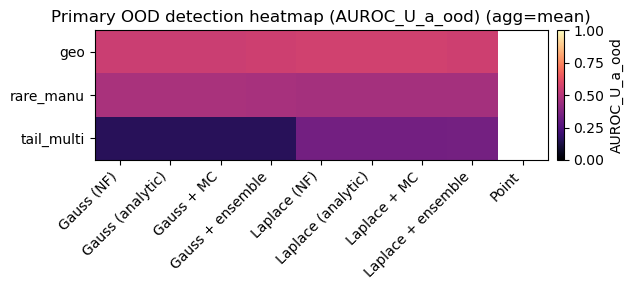

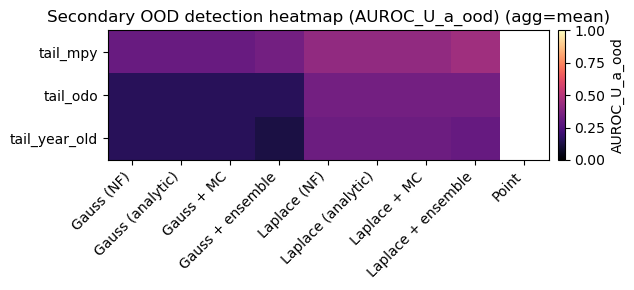

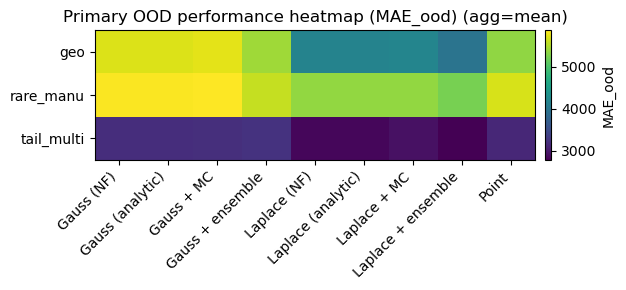

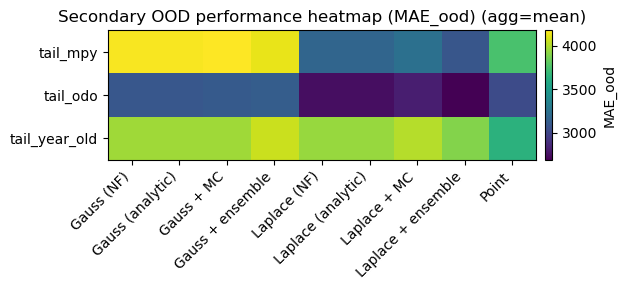

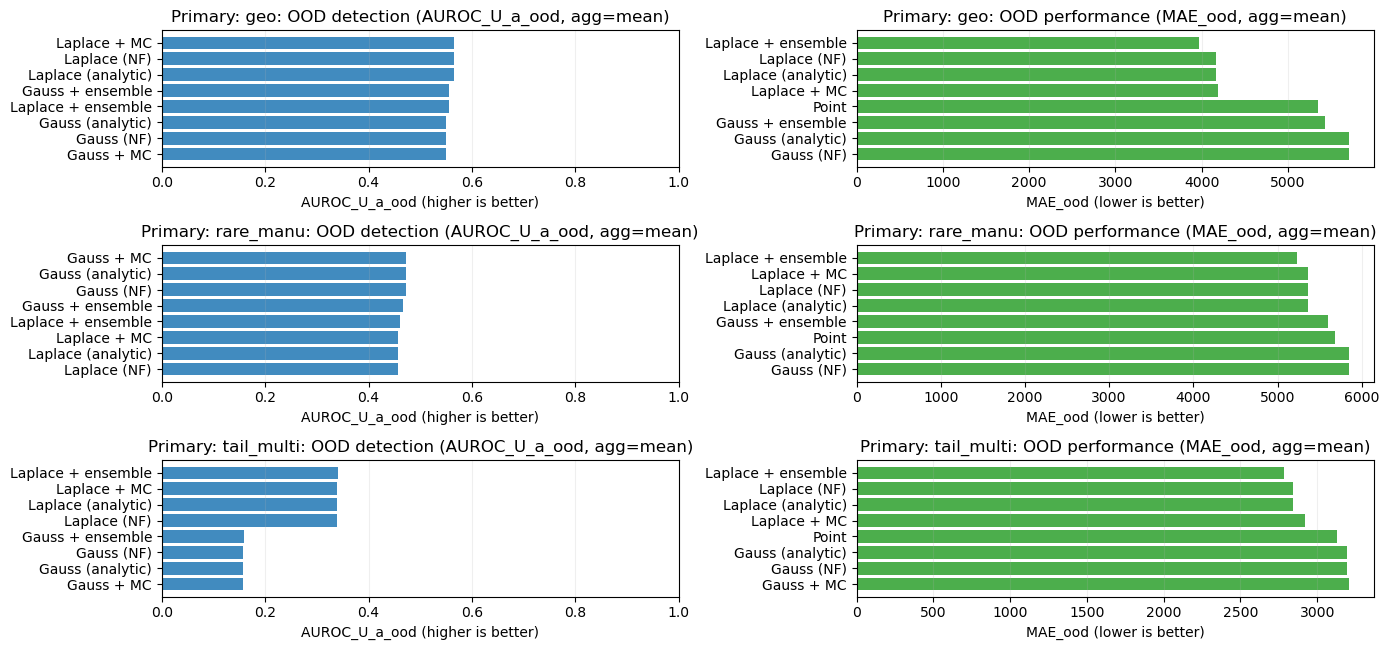

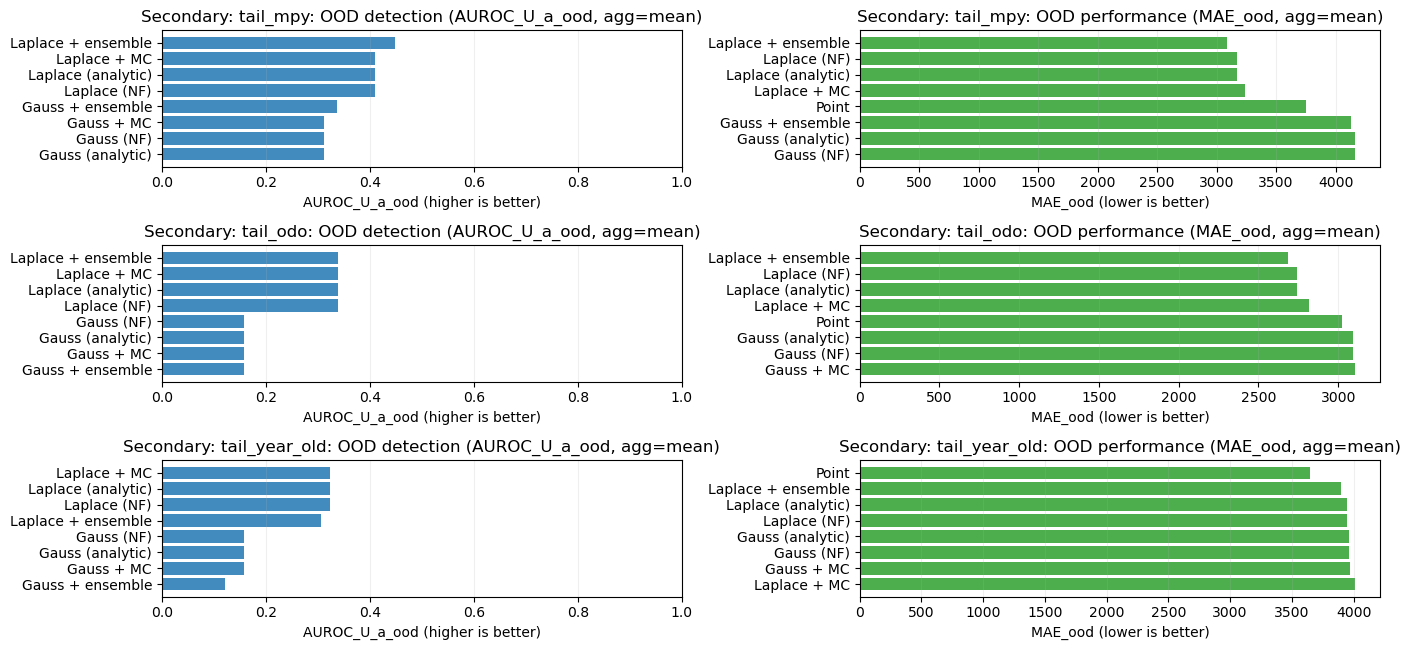

In [14]:
# OOD visualizations for df_ood_metrics (togglable)
PERF_METRIC = "MAE_ood"           # "MAE_ood" or "CRPS_ood"
DET_METRIC  = "AUROC_U_a_ood"     # "AUROC_U_total_ood", "AUROC_U_a_ood", "AUROC_U_e_ood"
AGG = "mean"                      # "mean" or "median"
TOP_K = 8
SHOW_HEATMAPS = True
SHOW_LEADERBOARDS = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "df_ood_metrics" not in globals() or df_ood_metrics is None or df_ood_metrics.empty:
    print("[warn] df_ood_metrics is empty; nothing to plot.")
else:
    PRIMARY_OOD = ["geo", "rare_manu", "tail_multi"]
    SECONDARY_OOD = ["tail_mpy", "tail_odo", "tail_year_old"]

    dfv = df_ood_metrics.copy()
    if "kind" in dfv.columns:
        dfv = dfv[dfv["kind"] != "dido"].copy()

    for required in ["dataset", "method", PERF_METRIC, DET_METRIC]:
        if required not in dfv.columns:
            raise ValueError(f"Missing required column in df_ood_metrics: {required}")

    if AGG not in {"mean", "median"}:
        raise ValueError("AGG must be 'mean' or 'median'")

    if "METHODS_OOD" in globals():
        method_order = [s.label for s in METHODS_OOD if s.label in set(dfv["method"])]
    else:
        method_order = sorted(dfv["method"].unique().tolist())

    def plot_heatmap(df_sub: pd.DataFrame, datasets: list[str], value_col: str, title: str, vmin=None, vmax=None, cmap="viridis"):
        ds_used = [d for d in datasets if d in set(df_sub["dataset"])]
        if not ds_used:
            print(f"[info] No datasets present for heatmap: {title}")
            return

        pv = (
            df_sub.pivot_table(index="dataset", columns="method", values=value_col, aggfunc=AGG)
            .reindex(index=ds_used, columns=method_order)
        )

        fig, ax = plt.subplots(figsize=(1.0 + 0.6 * pv.shape[1], 1.5 + 0.5 * pv.shape[0]))
        data = pv.to_numpy(float)
        masked = np.ma.masked_invalid(data)
        im = ax.imshow(masked, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax, cmap=cmap)

        ax.set_title(title + f" (agg={AGG})")
        ax.set_yticks(np.arange(len(pv.index)))
        ax.set_yticklabels(pv.index.tolist())
        ax.set_xticks(np.arange(len(pv.columns)))
        ax.set_xticklabels(pv.columns.tolist(), rotation=45, ha="right")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label(value_col)

        plt.tight_layout()
        plt.show()

    def plot_leaderboards(datasets: list[str], title_prefix: str):
        ds_used = [d for d in datasets if d in set(dfv["dataset"])]
        if not ds_used:
            return

        nrows = len(ds_used)
        fig, axes = plt.subplots(nrows, 2, figsize=(14, 2.2 * nrows), sharex=False)
        if nrows == 1:
            axes = np.array([axes])

        for i, ds in enumerate(ds_used):
            sub = dfv[dfv["dataset"] == ds].copy()

            # aggregate per method (if duplicates exist)
            det_agg = sub.groupby("method", as_index=False)[DET_METRIC].agg(AGG)
            perf_agg = sub.groupby("method", as_index=False)[PERF_METRIC].agg(AGG)

            # Detection (higher better)
            det = det_agg.dropna().sort_values(DET_METRIC, ascending=False).head(TOP_K)
            ax = axes[i, 0]
            ax.barh(det["method"][::-1], det[DET_METRIC][::-1], color="tab:blue", alpha=0.85)
            ax.set_title(f"{title_prefix} {ds}: OOD detection ({DET_METRIC}, agg={AGG})")
            ax.set_xlabel(f"{DET_METRIC} (higher is better)")
            if "AUROC" in DET_METRIC:
                ax.set_xlim(0.0, 1.0)
            ax.grid(True, axis="x", alpha=0.2)

            # Performance (lower better)
            perf = perf_agg.dropna().sort_values(PERF_METRIC, ascending=True).head(TOP_K)
            ax = axes[i, 1]
            ax.barh(perf["method"][::-1], perf[PERF_METRIC][::-1], color="tab:green", alpha=0.85)
            ax.set_title(f"{title_prefix} {ds}: OOD performance ({PERF_METRIC}, agg={AGG})")
            ax.set_xlabel(f"{PERF_METRIC} (lower is better)")
            ax.grid(True, axis="x", alpha=0.2)

        plt.tight_layout()
        plt.show()

    if SHOW_HEATMAPS:
        plot_heatmap(
            dfv[dfv["dataset"].isin(PRIMARY_OOD)],
            PRIMARY_OOD,
            DET_METRIC,
            f"Primary OOD detection heatmap ({DET_METRIC})",
            vmin=0.0 if "AUROC" in DET_METRIC else None,
            vmax=1.0 if "AUROC" in DET_METRIC else None,
            cmap="magma",
        )
        plot_heatmap(
            dfv[dfv["dataset"].isin(SECONDARY_OOD)],
            SECONDARY_OOD,
            DET_METRIC,
            f"Secondary OOD detection heatmap ({DET_METRIC})",
            vmin=0.0 if "AUROC" in DET_METRIC else None,
            vmax=1.0 if "AUROC" in DET_METRIC else None,
            cmap="magma",
        )
        plot_heatmap(
            dfv[dfv["dataset"].isin(PRIMARY_OOD)],
            PRIMARY_OOD,
            PERF_METRIC,
            f"Primary OOD performance heatmap ({PERF_METRIC})",
            cmap="viridis",
        )
        plot_heatmap(
            dfv[dfv["dataset"].isin(SECONDARY_OOD)],
            SECONDARY_OOD,
            PERF_METRIC,
            f"Secondary OOD performance heatmap ({PERF_METRIC})",
            cmap="viridis",
        )

    if SHOW_LEADERBOARDS:
        plot_leaderboards(PRIMARY_OOD, "Primary:")
        plot_leaderboards(SECONDARY_OOD, "Secondary:")


In [15]:
# (Removed debug STOP cell so "Run All" works.)
pass

## Notes

- This notebook is intentionally **file-first**: it loads one eval CSV at a time and produces small summary tables.
- If something looks off, debug by printing the exact `run_dir` and inspecting one CSV (columns + a few rows) rather than concatenating everything.
- Calibration remains **ID-val only**; OOD rows are never used to fit `alpha`/`beta`.


In [16]:
# NOTE: Loader overrides removed.
# The canonical loaders defined earlier now correctly read:
#   - OOD MC: `mc_preds_ood_<label>.csv`
#   - OOD ensemble: `ensemble_preds_ood_<label>.csv`
# Keeping this cell as a no-op to avoid confusing re-definitions.
pass


In [17]:
# Large-error detection on ID test: AUROC/AUPRC for U_a, U_e, U_total (plus DIDO if present).
try:
    from sklearn.metrics import roc_auc_score, average_precision_score
except Exception as e:
    roc_auc_score = None; average_precision_score = None
    print(f"[warn] sklearn not available; AUROC/AUPRC will be NaN. ({type(e).__name__}: {e})")

def auroc_auprc(y_true_bin, scores):
    y_true_bin = np.asarray(y_true_bin, int)
    scores = np.asarray(scores, float)
    mask = np.isfinite(scores)
    if np.unique(y_true_bin[mask]).size < 2 or roc_auc_score is None:
        return float('nan'), float('nan')
    return float(roc_auc_score(y_true_bin[mask], scores[mask])), float(average_precision_score(y_true_bin[mask], scores[mask])) if average_precision_score else float('nan')

rows = []
for spec in METHODS_CORE + METHODS_AUX:
    if spec.kind == "dido":
        # need joined DIDO + base preds to get y_true/mu if available; skip if missing
        df = method_id_frame_for_ood_detection(spec)
        if df is None or df.empty:
            continue
        if "dido_vacuity_raw" not in df.columns:
            continue
        scores = df["dido_vacuity_raw"].to_numpy(float)
        y_bin = (np.abs(df.get("y_true", pd.Series(np.nan, index=df.index)).to_numpy(float) - df.get("mu", pd.Series(np.nan, index=df.index)).to_numpy(float)) >= LARGE_ERROR_TAU).astype(int)
        auroc, auprc = auroc_auprc(y_bin, scores)
        rows.append({"method": spec.label, "score": "dido_vacuity", "AUROC": auroc, "AUPRC": auprc})
        continue

    df = method_id_frame_for_ood_detection(spec)
    if df is None or df.empty or "y_true" not in df.columns or "mu" not in df.columns:
        continue
    y = df["y_true"].to_numpy(float); mu = df["mu"].to_numpy(float)
    abs_err = np.abs(y - mu)
    y_bin = (abs_err >= LARGE_ERROR_TAU).astype(int)
    s_a, s_e, s_t = u_components(df, spec)
    for scores, label in [(s_a, "U_a"), (s_e, "U_e"), (s_t, "U_total")]:
        auroc, auprc = auroc_auprc(y_bin, scores)
        rows.append({"method": spec.label, "score": label, "AUROC": auroc, "AUPRC": auprc})

df_large_error = pd.DataFrame(rows)
display(df_large_error)



ValueError: too many values to unpack (expected 3)

In [ ]:
# DIDO logistic calibration (optional). Uses Laplace analytic ID-val + DIDO ID-val (if available).
try:
    from sklearn.linear_model import LogisticRegression
except Exception as e:
    LogisticRegression = None
    print(f"[warn] sklearn not available; skipping DIDO logistic calibration. ({type(e).__name__}: {e})")

dido_params = {}
if LogisticRegression is not None:
    # Attempt to load DIDO val; if not present, skip gracefully
    for head_key, head_type in [("dido_lpl", "laplace"), ("dido_gau", "gauss")]:
        run_dir = RUN_DIRS.get(head_key)
        base_dir = RUN_DIRS.get("lpl" if head_type == "laplace" else "gau")
        if run_dir is None or base_dir is None:
            continue
        try:
            df_dido = load_id_dido(run_dir)
            df_base = load_id_regression(base_dir, split="val", variant="analytic")
        except FileNotFoundError:
            continue
        if df_dido.empty or df_base.empty:
            continue
        # join on id
        df = df_dido.merge(df_base[["id", "y_true", "mu", "sigma_ale_raw"]], on="id", how="inner")
        if df.empty:
            continue
        # Build features
        X = np.column_stack([
            df.get("dido_vacuity_raw", pd.Series(np.nan, index=df.index)).to_numpy(float),
            df.get("dido_entropy_raw", pd.Series(np.nan, index=df.index)).to_numpy(float),
            df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float),
        ])
        y = (np.abs(df["y_true"].to_numpy(float) - df["mu"].to_numpy(float)) >= LARGE_ERROR_TAU).astype(int)
        mask = np.isfinite(X).all(axis=1)
        if np.unique(y[mask]).size < 2:
            continue
        clf = LogisticRegression(max_iter=200)
        clf.fit(X[mask], y[mask])
        dido_params[(head_type, "analytic")] = {
            "coef": clf.coef_.tolist(),
            "intercept": clf.intercept_.tolist(),
        }
    print("DIDO logistic params keys:", list(dido_params.keys()))



In [ ]:
# Noise-cohort analysis (optional, Laplace/Gauss analytic & NF). Skips if cohort columns unavailable.
cohort_options = [
    ["manufacturer", "model", "age_bucket"],
    ["make", "model", "age_bucket"],
    ["manufacturer", "model", "vehicle_age_bucket"],
    ["make", "model", "vehicle_age_bucket"],
]
FEATURES_PATH = PROJECT_ROOT / "datasets" / "craigslist_cleaned_FULL.csv"
cohort_min_size = 100
cohort_cols = None

if FEATURES_PATH.exists():
    df_feat = pd.read_csv(FEATURES_PATH, usecols=lambda c: c == "id" or any(c in opt for opt in cohort_options) if True else False)
    for opt in cohort_options:
        if set(opt).issubset(df_feat.columns):
            cohort_cols = opt
            break
else:
    print(f"[warn] Features file not found: {FEATURES_PATH}")

if cohort_cols is None:
    print(f"[warn] No cohort columns found; skipping noise-cohort analysis.")
else:
    cohort_lookup = df_feat[['id'] + cohort_cols].drop_duplicates()
    rows = []
    for spec in METHODS_AUX + METHODS_CORE:
        if spec.epistemic_source != "none" or spec.aleatoric_source not in {"analytic", "nf"}:
            continue
        # use test split
        if spec.kind == "nf":
            df_pred = load_id_nf(RUN_DIRS[spec.key])
        else:
            df_pred = method_id_test_frame(spec)
        if df_pred.empty or not {'id','y_true','mu'}.issubset(df_pred.columns):
            continue
        df_pred = df_pred.merge(cohort_lookup, on='id', how='left')
        df_pred['resid'] = df_pred['y_true'] - df_pred['mu']
        df_pred['sigma_ale_sq_cal'] = (u_components(df_pred, spec)[0] ** 2) if u_components(df_pred, spec)[0] is not None else np.nan
        grp = df_pred.groupby(cohort_cols)
        tbl = grp.agg(n=("resid","size"), var_resid=("resid", lambda x: float(np.var(x, ddof=0))), mean_sigma_ale_sq=("sigma_ale_sq_cal","mean")).reset_index()
        tbl = tbl[tbl['n'] >= cohort_min_size].copy()
        if tbl.empty:
            continue
        corr = tbl['var_resid'].corr(tbl['mean_sigma_ale_sq'])
        slope = np.polyfit(tbl['mean_sigma_ale_sq'], tbl['var_resid'], 1)[0] if len(tbl) >= 2 else np.nan
        rows.append({"method": spec.label, "head_type": spec.head_type, "aleatoric_source": spec.aleatoric_source, "n_cohorts": int(tbl.shape[0]), "corr(var_resid,E[sigma_a^2])": float(corr), "slope": float(slope) if np.isfinite(slope) else np.nan})
    df_noise_summary = pd.DataFrame(rows)
    display(df_noise_summary)



In [ ]:
# NF vs analytic comparison (coverage/reliability). Skips if NF files missing.
from scipy.stats import norm
nominal = np.arange(10, 100, 10)
z_lookup = {p: norm.ppf((1+p/100)/2) for p in nominal}

def coverage_vals(df, spec):
    y = df["y_true"].to_numpy(float); mu = df["mu"].to_numpy(float)
    s_a, s_e, s_t = u_components(df, spec)
    if s_t is None:
        return None
    err = np.abs(y - mu)
    return [float(np.mean(err <= z_lookup[p]*s_t)) for p in nominal]

nf_rows = []
for ht, nf_key in [("laplace","nf_lpl"),("gauss","nf_gau")]:
    nf_dir = RUN_DIRS.get(nf_key)
    base_dir = RUN_DIRS.get("lpl" if ht=="laplace" else "gau")
    if nf_dir is None or base_dir is None:
        continue
    df_nf = load_id_nf(nf_dir)
    df_base = load_id_regression(base_dir, split="test", variant="analytic")
    for df, label, spec in [(df_base, f"{ht} analytic", MethodSpec(f"{ht}_analytic","",ht,"analytic","none","regression")), (df_nf, f"{ht} NF", MethodSpec(f"nf_{ht}","",ht,"nf","none","nf"))]:
        cov = coverage_vals(df, spec)
        if cov is None:
            continue
        nf_rows.append({"method": label, **{f"cov_{p}": c for p,c in zip(nominal,cov)}})

df_nf_cov = pd.DataFrame(nf_rows)
display(df_nf_cov)



In [ ]:
# Data-size experiment stub (train_frac variants). Skips if multiple train_fracs not present.
# If you have runs with different train_frac encoded in filenames or metadata, plug them here.
print("[info] Data-size experiment not implemented (no multiple train_frac runs detected). Add logic once available.")

